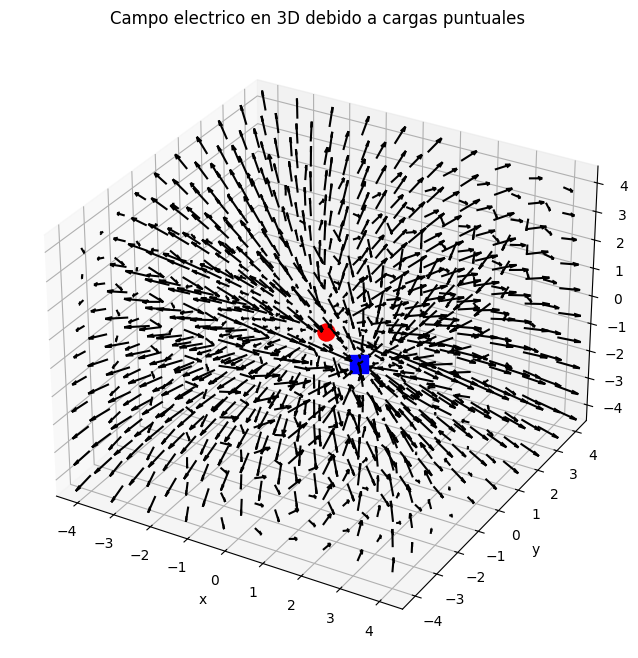

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from mpl_toolkits.mplot3d import Axes3D

# =====================================================
# CAMPO ELECTRICO EN 3D DEBIDO A CARGAS PUNTUALES
# =====================================================

# -----------------------------
# Malla 3D
# -----------------------------
N = 10
x = np.linspace(-4, 4, N)
y = np.linspace(-4, 4, N)
z = np.linspace(-4, 4, N)

# -----------------------------
# Configuracion de cargas
# Cada carga: [x0, y0, z0, q]
# -----------------------------
cargas = np.array([
    [0.0,  0.0,  0.0,  1.0],
    [2.0, -2.0,  1.0, -1.0]
])

# -----------------------------
# Funcion de campo puntual en 3D
# -----------------------------
def campo_puntual_3d(x, y, z, x0, y0, z0, q):
    dx = x - x0
    dy = y - y0
    dz = z - z0

    r2 = dx**2 + dy**2 + dz**2
    r = np.sqrt(r2)

    if r < 1e-6:
        return 0.0, 0.0, 0.0

    factor = q / r**3
    Ex = factor * dx
    Ey = factor * dy
    Ez = factor * dz

    return Ex, Ey, Ez

# -----------------------------
# Crear figura 3D
# -----------------------------
fig = plt.figure(figsize=(9, 8))
ax = fig.add_subplot(111, projection='3d')

# -----------------------------
# Dibujar vectores del campo
# -----------------------------
for i in range(N):
    for j in range(N):
        for k in range(N):

            Ex_total = 0.0
            Ey_total = 0.0
            Ez_total = 0.0

            for carga in cargas:
                x0, y0, z0, q = carga
                ex, ey, ez = campo_puntual_3d(x[i], y[j], z[k], x0, y0, z0, q)

                Ex_total += ex
                Ey_total += ey
                Ez_total += ez

            ax.quiver(x[i], y[j], z[k],
                      Ex_total, Ey_total, Ez_total,
                      length=0.6, normalize=True, color='black')

# -----------------------------
# Dibujar cargas
# -----------------------------
for carga in cargas:
    x0, y0, z0, q = carga

    if q > 0:
        ax.scatter(x0, y0, z0, s=150, color='red')
    else:
        ax.scatter(x0, y0, z0, s=150, color='blue', marker='s')

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Campo electrico en 3D debido a cargas puntuales")

plt.savefig("Campo3D.pdf", dpi=300, bbox_inches="tight")
plt.show()

files.download("Campo3D.pdf")